# German Traffic Sign Recognition (GTSRB) using CNN

This notebook builds an image classification model from scratch to recognize German traffic signs using the **GTSRB (German Traffic Sign Recognition Benchmark)** dataset.

### Key steps:
- **Dataset:** GTSRB — 43 traffic sign classes, with separate `Train` (class-labeled folders) and `Test` (CSV-labeled) sets
- **Model:** Custom CNN built from scratch (Conv2D → BatchNormalization → Activation → MaxPooling blocks, repeated 3 times), followed by a Dense classifier head with Dropout for regularization
- **Preprocessing:** Images resized to 64x64, normalized via a `Rescaling` layer; test images cropped using the provided ROI (Region of Interest) coordinates to match the framing of training images
- **Training:** Adam optimizer with `sparse_categorical_crossentropy` loss, trained for 30 epochs
- **Evaluation:** Training/validation accuracy and loss curves, plus final evaluation on the held-out Test set (using `Test.csv` labels, correctly remapped to match the model's internal class indexing)
- **Inference:** Single-image prediction on external traffic sign images

### Results:
- Training accuracy: ~99%
- Validation accuracy: ~99.7%
- Test accuracy: ~98.2%

### Goal:
Build a reliable, lightweight CNN that can correctly classify traffic sign images into one of 43 categories — useful for applications like autonomous driving and driver-assistance systems.

In [3]:
# !mkdir -p ~/.kaggle
# !cp kaggle.json ~/.kaggle/

In [4]:
# !kaggle datasets download -d meowmeowmeowmeowmeow/gtsrb-german-traffic-sign

In [5]:
# import zipfile
# zip_ref = zipfile.ZipFile('/content/gtsrb-german-traffic-sign.zip')
# zip_ref.extractall('/content')
# zip_ref.close()


## Library import

In [6]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models, Sequential
from sklearn.model_selection import train_test_split

from tensorflow.keras.layers import Activation, Rescaling, Flatten, Conv2D, Dense, MaxPooling2D, BatchNormalization, GlobalAvgPool2D, GlobalMaxPooling2D, LeakyReLU, Dropout
from tensorflow.keras.applications import MobileNetV2

## dataset split

In [7]:
from sklearn.utils import validation
dataset_path = '/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Train'

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split = .2,
    subset = 'training',
    seed = 42,
    image_size = (64, 64),
    batch_size = 32
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split = .2,
    subset = 'validation',
    seed = 42,
    image_size = (64, 64),
    batch_size = 32
)

Found 39209 files belonging to 43 classes.
Using 31368 files for training.


I0000 00:00:1782282536.040291      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782282536.046589      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 39209 files belonging to 43 classes.
Using 7841 files for validation.


## Simple CNN from scratch

In [8]:
model = Sequential([

    Rescaling(1./ 255 , input_shape = (64, 64, 3)),

    Conv2D(32, (3,3)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(43, activation='softmax')  # 43 classes

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 29, 29, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,285,099 (4.90 MB)

 Trainable params: 1,284,651 (4.90 MB)

 Non-trainable params: 448 (1.75 KB)

In [10]:
# Compile Model

model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

In [11]:
history = model.fit(train_ds, validation_data  = validation_ds, epochs=30)

Epoch 1/30


I0000 00:00:1782282545.037296     146 service.cc:152] XLA service 0x7ff0e40059d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782282545.037351     146 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782282545.037355     146 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782282545.613714     146 cuda_dnn.cc:529] Loaded cuDNN version 91002


  7/981 ━━━━━━━━━━━━━━━━━━━━ 23s 24ms/step - accuracy: 0.0192 - loss: 5.7104    

I0000 00:00:1782282549.897670     146 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


981/981 ━━━━━━━━━━━━━━━━━━━━ 60s 54ms/step - accuracy: 0.4876 - loss: 1.7116 - val_accuracy: 0.9027 - val_loss: 0.4080
Epoch 2/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.7180 - loss: 0.8055 - val_accuracy: 0.9489 - val_loss: 0.2219
Epoch 3/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.7660 - loss: 0.6495 - val_accuracy: 0.9608 - val_loss: 0.1533
Epoch 4/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.7908 - loss: 0.5832 - val_accuracy: 0.9765 - val_loss: 0.0994
Epoch 5/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.8084 - loss: 0.5262 - val_accuracy: 0.9872 - val_loss: 0.0683
Epoch 6/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.8185 - loss: 0.4952 - val_accuracy: 0.9918 - val_loss: 0.0694
Epoch 7/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.8289 - loss: 0.4619 - val_accuracy: 0.9884 - val_loss: 0.0565
Epoch 8/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.8381 - loss: 0.4383 - val_accurac

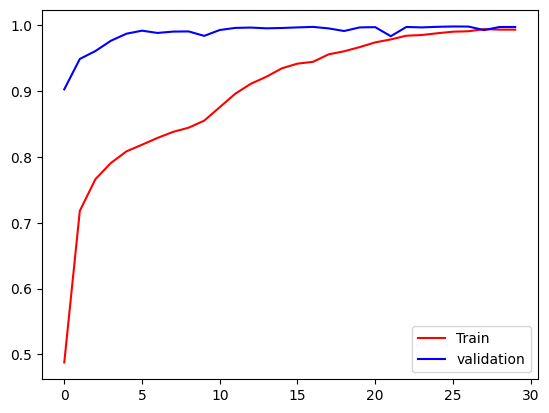

In [12]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], color = 'red', label = "Train")
plt.plot(history.history['val_accuracy'], color = 'blue', label = "validation")
plt.legend()
plt.show()

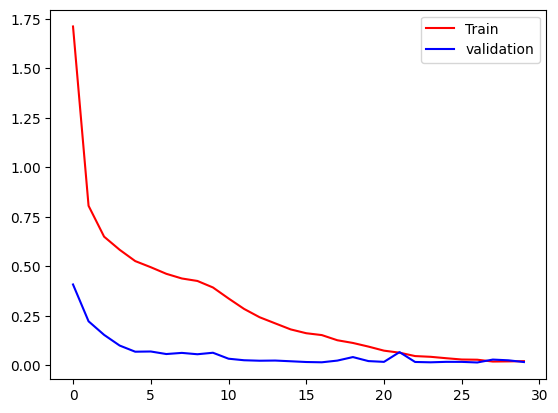

In [13]:


plt.plot(history.history['loss'], color = 'red', label = "Train")
plt.plot(history.history['val_loss'], color = 'blue', label = "validation")
plt.legend()
plt.show()

In [16]:

from tensorflow.keras.utils import img_to_array, load_img
from tensorflow.keras.preprocessing import image
import numpy as np



sign1 = "/kaggle/input/datasets/abdullah65621/signs-for-test/sign-1.png"

img = image.load_img(sign1, target_size = (64, 64))
x = img_to_array(img)
x = np.expand_dims(x, axis=0) # (height, width, channels) -> (batch_size, height, width, channels)


In [17]:
print(train_ds.class_names)

['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '5', '6', '7', '8', '9']


In [18]:
# prediction
class_name = ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '5', '6', '7', '8', '9']


preds = model.predict(x)

top_index = np.argmax(preds[0])

print("predicted class : ", class_name[top_index])
print("Confidence : ", round(preds[0][top_index] * 100, 2) , "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 557ms/step
predicted class :  26
Confidence :  100.0 %


In [19]:
import pandas as pd
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array

test_csv = pd.read_csv('/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Test.csv')
print(test_csv.head())

   Width  Height  Roi.X1  Roi.Y1  Roi.X2  Roi.Y2  ClassId            Path
0     53      54       6       5      48      49       16  Test/00000.png
1     42      45       5       5      36      40        1  Test/00001.png
2     48      52       6       6      43      47       38  Test/00002.png
3     27      29       5       5      22      24       33  Test/00003.png
4     60      57       5       5      55      52       11  Test/00004.png


In [35]:
dataset_root = '/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/'

X_test = []
Y_test = []

for _, row in test_csv.iterrows():
    img_path = dataset_root + row['Path']
    img = load_img(img_path, target_size = (64, 64))
    img_array = img_to_array(img)

    X_test.append(img_array)
    Y_test.append(row['ClassId'])

X_test = np.array(X_test)
Y_test = np.array(Y_test)

print(X_test.shape)
print(Y_test.shape)
    

(12630, 64, 64, 3)
(12630,)


In [36]:
test_loss, test_accuracy = model.evaluate(X_test, Y_test)
print(f"Test Accuracy : {test_accuracy * 100 : .2f}")
print(f"Test loss : {test_loss * 100 : .2f}")

395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0614 - loss: 60.7459
Test Accuracy :  6.14
Test loss :  6074.59


In [38]:

class_names = train_ds.class_names   

classid_to_index = {int(name): idx for idx, name in enumerate(class_names)}

y_test_mapped = np.array([classid_to_index[label] for label in y_test])

test_loss, test_accuracy = model.evaluate(X_test, y_test_mapped)
print(f"Test Accuracy : {test_accuracy * 100 : .2f}")
print(f"Test loss : {test_loss : .2f}")

395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9819 - loss: 0.0892
Test Accuracy :  98.19
Test loss :  0.09
